In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%cd ../../..

/Users/dave/Library/CloudStorage/OneDrive-PolitecnicodiMilano/PhD/Repositories/DT-rse


## Test Adaptation Phase

In this notebook, we test the adaptation phase of the OL routine with an offline dataset generated by the estimation routine. The idea is to validate the method and create a new faulty cluster from the outlier set.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from pathlib import Path
from scipy import signal

from ernesto.postprocessing.visualization import ernesto_plotter
from ernesto.adaptation.regime_shift.stats import *

In [10]:
folder =folder = "data/output/adaptive/"
folder = folder + 'region_shift_experiment/test_optimization/1_5M_300estimates_new/'
path = Path(folder)

In [11]:
samples_file = 'parameter_evolution.csv'
# ground_file = 'ground_0.csv'
# sim_file = 'dataset_0.csv'

df_samples = pd.read_csv(path / samples_file)
# df_ground = pd.read_csv(path / ground_file)
# df_sim = pd.read_csv(path / sim_file)

In [12]:
df_samples

,soc,temperature,r0,r1,c1,cluster,is_outlier,time_step
0,1.000000,303.150000,0.002198,0.002480,22966.778613,nominal_temp_40,False,0
1,0.800000,303.150000,0.002238,0.002910,24140.464793,nominal_temp_40,False,0
2,0.600000,303.150000,0.002271,0.002205,20859.505625,nominal_temp_40,False,0
3,0.500000,303.150000,0.002291,0.002436,22622.611802,nominal_temp_40,False,0
4,0.400000,303.150000,0.002308,0.002862,26234.314231,nominal_temp_40,False,0
...,...,...,...,...,...,...,...,...
309,0.611111,283.173116,0.004181,0.004323,13702.556745,NaN,True,296
310,0.600708,283.173396,0.004217,0.004288,13681.560871,NaN,True,297
311,0.600681,283.173113,0.003793,0.004640,12140.733136,NaN,True,298
312,0.611111,283.173116,0.004180,0.004324,13696.750787,NaN,True,299


In [13]:
def adapation_routine(clusters: dict, outliers: list, options: dict, times: np.ndarray):
    """
    Adaptation routine
    """
    mus = []
    sigmas = []
    supports = []
    indices = []
    
    if len(outliers) > options['min_number_outliers']:
        
        # Perform KS tests between each cluster and the outliers    
        ks_result = True
        for idx, cluster in enumerate(clusters.values()):
            _, p = ks_test(cluster, outliers)
            
            # If p-value is greater than alpha_ks, we consider the distributions similar (H0 not rejected)
            if p > options['alpha_ks']:  # not significantly different
                ks_result = False
              
        # If all KS tests passed, look for a new cluster
        if ks_result:

            #print(f'KS test passed with alpha {options['alpha_ks']} and p_value {p}')
            
            # Use KDE-based mountain method to find the new cluster centroid and MinCovDet to estimate its covariance
            #mu = kde_mountain_method(outliers=outliers, bandwidth=options['bandwidth'], n_candidates=options['n_candidates'])
            #print(f'Mountain method with bandwith {options['bandwidth']} and {options['n_candidates']} candidates outputs a centroid {mu}')

            # Use grid-based mountain method to find the new cluster centroid and MinCovDet to estimate its covariance
            centers, indices, _, _ = grid_mountain_method(points=outliers, 
                                                           times=times,
                                                           grid_size=options['grid_size'],
                                                           radius=options['radius'],
                                                           max_potential=options['max_potential'],
                                                           lambda_=options['lambda'],
                                                           beta=options['beta'],
                                                           eta=options['eta'],
                                                           curr_time=df_samples.iloc[-1]['time_step'])
            print(f'Mountain method with grid_size {options['grid_size']} outputs centroids {centers}\n')

            supports = [outliers[idx] for idx in indices]
            indices = []
            
            for center, supp in zip(centers, supports):
                print(f"Center: {center}")
                if len(supp) > 3:
                    mu, sigma, idx_list = mcd_with_center(points=supp,
                                                          center=center,
                                                          distance=options['distance'],
                                                          k=options['k-neighbours'],
                                                          support_fraction=options['support_fraction'],
                                                          alpha=options['alpha_mcd'],
                                                          max_refine_iters=options['max_refine_iters']
                                                         )
        
                    print(f'MCD procedure outputs a centroid {mu}, covariance {sigma} and support {idx_list} with length {len(idx_list)}')
    
                    # If we have enough outliers, create a new cluster
                    if len(idx_list) > options['min_number_outliers']:
                        print(f"New cluster creation with center {center}")
                    else:
                        print(f"ERROR: Not enough points to be included within the faulty cluster with center {center}!")
                    print('\n')
                    
                    mus.append(mu)
                    sigmas.append(sigma)
                    indices.append(idx_list)
                else:
                    print(f'ERROR: Not enough points in the support of the center {center}')
        else:
            print("ERROR: KS test not passed!")
        
    else:
        print("ERROR: Not enough outliers samples!")

    return np.array(mus), sigmas, indices

In [14]:
cluster = df_samples[~df_samples['is_outlier']]
outliers = df_samples[df_samples['is_outlier']]

In [15]:
#cluster

In [16]:
#outliers

#### Complete routine

In [ ]:
params = ['r0', 'r1', 'c1']
options = {
    'min_number_outliers': 15,
    'alpha_ks': 0.01,
    'grid_size': 30,
    'radius': 0.3,
    'max_potential': 1e-3,
    'lambda': 0.8,
    'beta': 1.5,
    'eta': 1e-1,
    'bandwidth': 0.2,
    'n_candidates': 200,
    'k-neighbours': 50,
    'distance': 'maha',
    'threshold_for_maha': 'fisher',
    'alpha_mcd': 0.01,
    'support_fraction': 1,
    'max_refine_iters': 0
}

In [ ]:
# Centri trovati alla fine di tutta la routine
mus, sigmas, supports = adapation_routine(clusters={'nominal': cluster[params].to_numpy()}, 
                                          outliers=outliers[params].to_numpy(), 
                                          options=options,
                                          times=outliers['time_step'].to_numpy())

In [ ]:
supports

In [ ]:
X = outliers[params].to_numpy()

# Plot results
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

colors = sns.color_palette("hls", 30)

# Original data points
for i, (mu, support) in enumerate(zip(mus, supports)):
    if len(support) > 3:
        ax.scatter(mu[0], mu[1], mu[2], marker="x", s=100, color=colors[i], alpha=1)
        ax.scatter(X[support, 0], X[support, 1], X[support, 2], color=colors[i], alpha=1, label=f"Support {i} - {len(support)}")

ax.set_xlabel("R0")
ax.set_ylabel("R1")
ax.set_zlabel("C1")
ax.set_title("Mountain Method (3D)")
ax.legend()

plt.show()

In [ ]:
mus

In [ ]:
Y = cluster[params].to_numpy()
X = outliers[params].to_numpy()

# Plot results
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

mu = mus[2]
support = supports[2]

# Faulty cluster data points
ax.scatter(X[support, 0], X[support, 1], X[support, 2], c="orange", alpha=0.9, label="Faulty Cluster")
# Faulty Cluster center
ax.scatter(mu[0], mu[1], mu[2], c="red", marker="x", s=100, alpha=1)

# Original cluster
ax.scatter(Y[:, 0], Y[:, 1], Y[:, 2], c='blue', alpha=0.9, label="Original Data")

ax.set_xlabel("R0")
ax.set_ylabel("R1")
ax.set_zlabel("C1")
ax.set_title("Orig and new cluster")
ax.legend()

plt.show()

---

### Analysis of Mountain Method

In [ ]:
params = ['r0', 'r1', 'c1']
options = {
    'min_number_outliers': 15,
    'alpha_ks': 0.01,
    'grid_size': 30,
    'radius': 0.3,
    'max_potential': 1e-3,
    'lambda': 0.8,
    'beta': 1.5,
    'eta': 1e-1,
    'bandwidth': 0.2,
    'n_candidates': 200,
    'k-neighbours': 50,
    'distance': 'maha',
    'threshold_for_maha': 'fisher',
    'alpha_mcd': 0.01,
    'support_fraction': 0.8,
    'max_refine_iters': 0
}

In [ ]:
# Centri trovati con Mountain Method
X = outliers[params].to_numpy()
times = outliers['time_step'].to_numpy()

centers, supports, grid_points, potentials = grid_mountain_method(points=X, 
                                                                  times=times,
                                                                  grid_size=options['grid_size'],
                                                                  radius=options['radius'],
                                                                  max_potential=options['max_potential'],
                                                                  beta=options['beta'],
                                                                  eta=options['eta'])

# Plot results
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Grid points with potentials as color
#sc = ax.scatter(grid_points[:, 0], grid_points[:, 1], grid_points[:, 2],
#                c=potentials, cmap="viridis", s=10, alpha=0.1, label="Potentials")

# Original data points
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c="orange", alpha=0.2, label="Data")

idx = np.argmax([len(support) for support in supports])

# Cluster
ax.scatter(supports[idx][:,0], supports[idx][:,1], supports[idx][:,2], c="red", alpha=1)
ax.scatter(centers[idx, 0], centers[idx, 1], centers[idx, 2], c="red", marker="x", s=100, label=f"Center_{idx}", alpha=1)

print(supports[idx][:,0])

ax.set_xlabel("R0")
ax.set_ylabel("R1")
ax.set_zlabel("C1")
ax.set_title("Mountain Method (3D)")
ax.legend()

fig.colorbar(sc, ax=ax, shrink=0.6, label="Potential")
plt.show()

In [ ]:
centers

### Analysis of K-Nearest Neighbours

In [ ]:
# 1) Candidate pool: k-NN around the center (fallback to all if N<k)
def knn(points: np.ndarray, center: np.ndarray, distance: str = 'euclidean',  k: int = 10):
    N, p = points.shape
    
    if distance == 'maha':
        # Empirical covariance
        cov = np.cov(points, rowvar=False)
        cov_inv = np.linalg.inv(cov + np.eye(p)*1e-9)  # stabilize inverse
        
        # Mahalanobis distances to center
        d_to_center = np.array([mahalanobis(x, center, cov_inv) for x in points])
    
    elif distance == 'euclidean':
        d_to_center = cdist(points, center.reshape(1, -1)).ravel()
    
    else:
        raise ValueError("Distance metric not recognized.")
        
    k_eff = min(k, N)
    cand_idx = np.argpartition(d_to_center, k_eff-1)[:k_eff]
    X_cand = points[cand_idx]
    return X_cand

In [ ]:
for center in centers:
    neighbours = knn(points=outliers[params].to_numpy(), center=center, k=10, distance='maha')
    print(f"Center:  {center}\nNeighbours: {neighbours}\n")

In [ ]:
X = outliers[params].to_numpy()
times = outliers['time_step'].to_numpy()
centers, grid_points, potentials = grid_mountain_method(points=X, 
                                                        times=times,
                                                        grid_size=options['grid_size'],
                                                        radius=options['radius'],
                                                        max_potential=options['max_potential'],
                                                        beta=options['beta'])

# Plot results
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Cluster centers
ax.scatter(centers[:, 0], centers[:, 1], centers[:, 2], c="red", marker="x", s=100, label="Centers", alpha=1)

colors = ['red', 'orange', 'green']
for i, center in enumerate(centers):
    neighbours = knn(points=X, center=center, k=10, distance='maha')
    ax.scatter(neighbours[:, 0], neighbours[:, 1], neighbours[:, 2], c=colors[i], s=100, alpha=1, label=f"Center {i}")
    
# Original data points
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c="blue", alpha=0.1, label="Outliers")

ax.set_xlabel("R0")
ax.set_ylabel("R1")
ax.set_zlabel("C1")
ax.set_title("Mountain Method (3D)")
ax.legend()

plt.show()

---

## Analysis Mountain Method from Trovò

In [20]:
params = ['r0', 'r1', 'c1']
options = {
    'min_number_outliers': 15,
    'alpha_ks': 0.01,
    'grid_size': 30,
    'radius': 0.075,
    'max_potential': 1e-3,
    'lambda': 0.8,
    'beta': 1.5,
    'eta': 1e-6,
    'bandwidth': 0.2,
    'n_candidates': 200,
    'k-neighbours': 50,
    'distance': 'maha',
    'threshold_for_maha': 'fisher',
    'alpha_mcd': 0.01,
    'support_fraction': 0.8,
    'max_refine_iters': 0
}

In [21]:
# Centri trovati con Mountain Method
X = outliers[params].to_numpy()
times = outliers['time_step'].to_numpy()

center, support, centers, clu_indices = trovo_mountain_method(points=X, 
                                                              times=times,
                                                              curr_time=len(X),
                                                              lambda_=options['lambda'],
                                                              radius=options['radius'],
                                                              eta=options['eta'],
                                                              max_iter=1000)

Iteration 0, max center change: 1.17567921145803
Iteration 1, max center change: 0.22353080744139886
Iteration 2, max center change: 0.10048458985579502
Iteration 3, max center change: 0.059690502914247094
Iteration 4, max center change: 0.043351616985197024
Iteration 5, max center change: 0.03902384991802438
Iteration 6, max center change: 0.03630956443453289
Iteration 7, max center change: 0.03481607143211815
Iteration 8, max center change: 0.03430251849016425
Iteration 9, max center change: 0.03455089595909439
Iteration 10, max center change: 0.03547998973403815
Iteration 11, max center change: 0.037052256584885986
Iteration 12, max center change: 0.03922716108303841
Iteration 13, max center change: 0.041925875630823776
Iteration 14, max center change: 0.04533993788792796
Iteration 15, max center change: 0.04944647961679668
Iteration 16, max center change: 0.05422279133928354
Iteration 17, max center change: 0.059670758596015415
Iteration 18, max center change: 0.06557844583180501
I

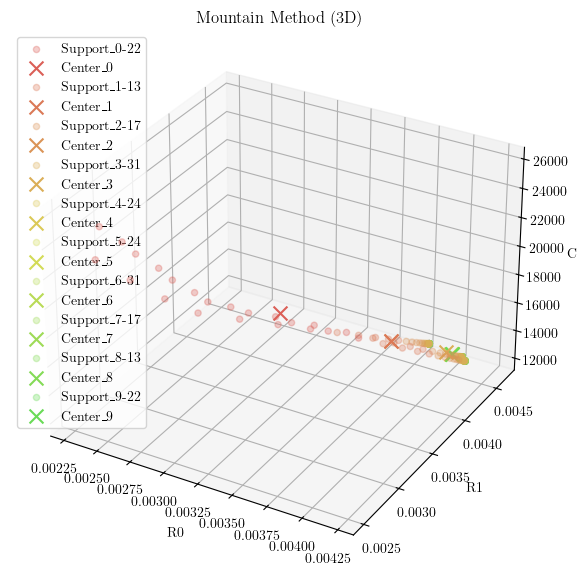

In [22]:
# Plot results
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

colors = sns.color_palette("hls", 30)
i = 0

# Cluster
for c, indices in zip(centers, clu_indices):
    if len(indices) > 3:
        ax.scatter(X[indices, 0], X[indices, 1], X[indices,2], color=colors[i], alpha=0.3, label=f"Support_{i}-{len(indices)}")
        ax.scatter(c[0], c[1], c[2], color=colors[i], marker="x", s=100, label=f"Center_{i}", alpha=1)
        i += 1

ax.set_xlabel("R0")
ax.set_ylabel("R1")
ax.set_zlabel("C1")
ax.set_title("Mountain Method (3D)")
ax.legend()

plt.show()

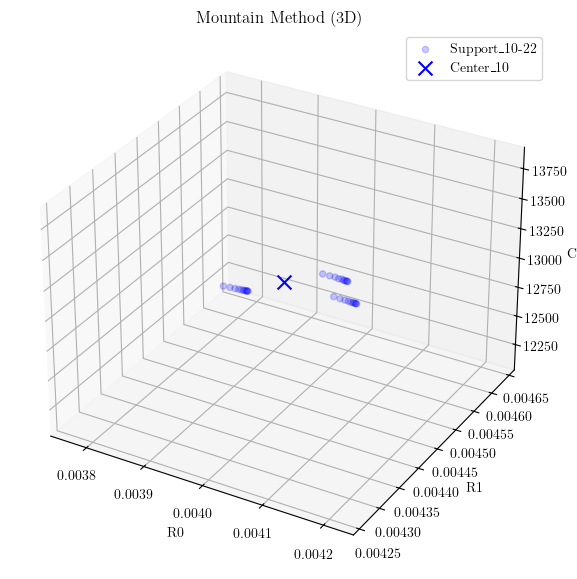

In [23]:
# Plot results
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

colors = sns.color_palette("hls", 30)

# Cluster
ax.scatter(X[support, 0], X[support, 1], X[support,2], color="blue", alpha=0.2, label=f"Support_{i}-{len(indices)}")
ax.scatter(center[0], center[1], center[2], color="blue", marker="x", s=100, label=f"Center_{i}", alpha=1)

ax.set_xlabel("R0")
ax.set_ylabel("R1")
ax.set_zlabel("C1")
ax.set_title("Mountain Method (3D)")
ax.legend()

plt.show()

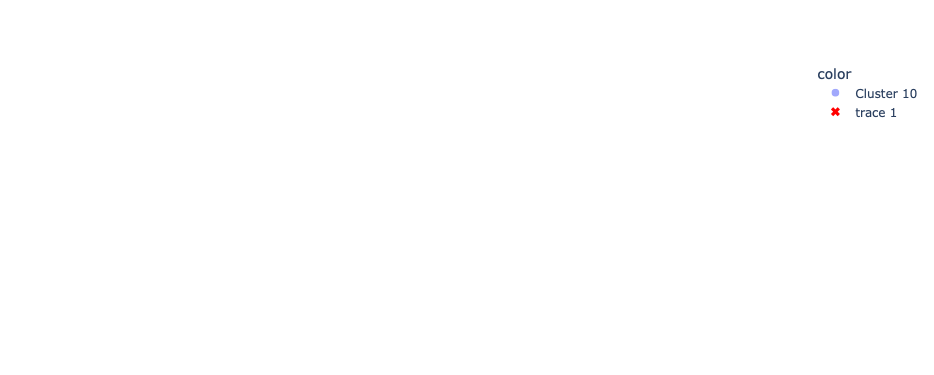

In [24]:
import plotly.express as px
fig = px.scatter_3d(x=X[support, 0], y=X[support, 1], z=X[support, 2],
                    color=[f"Cluster {i}"]*len(support), opacity=0.6)
fig.add_scatter3d(x=[center[0]], y=[center[1]], z=[center[2]],mode="markers", marker=dict(size=8, color="red", symbol="x"))
fig.show()

## Complete Trovo Routine

In [17]:
params = ['r0', 'r1', 'c1']
options = {
    'min_number_outliers': 15,
    'alpha_ks': 0.01,
    'grid_size': 30,
    'radius': 0.1,
    'max_potential': 1e-3,
    'lambda': 0.8,
    'beta': 1.5,
    'eta': 1e-6,
    'bandwidth': 0.2,
    'n_candidates': 200,
    'k-neighbours': 50,
    'distance': 'maha',
    'threshold_for_maha': 'fisher',
    'alpha_mcd': 0.01,
    'support_fraction': 1.,
    'max_refine_iters': 0
}

In [18]:
def trovo_adapation_routine(clusters: dict, outliers: list, options: dict, times: np.ndarray):
    """
    Adaptation routine
    """
    mus = []
    sigmas = []
    supports = []
    indices = []
    
    if len(outliers) > options['min_number_outliers']:
        
        # Perform KS tests between each cluster and the outliers    
        ks_result = True
        for idx, cluster in enumerate(clusters.values()):
            _, p = ks_test(cluster, outliers)
            
            # If p-value is greater than alpha_ks, we consider the distributions similar (H0 not rejected)
            if p > options['alpha_ks']:  # not significantly different
                ks_result = False
              
        # If all KS tests passed, look for a new cluster
        if ks_result:

            # Use mountain method to find the new cluster centroid and MinCovDet to estimate its covariance
            center, indices, _, _ = trovo_mountain_method(points=X, 
                                                    times=times,
                                                    curr_time=len(X),
                                                    lambda_=options['lambda'],
                                                    radius=options['radius'],
                                                    eta=options['eta'],
                                                    max_iter=1000)
            
            print(f'Mountain method outputs center {center} with support of {len(indices)}\n')
            support = outliers[indices]
            
            if len(indices) > 3:
                mu, sigma, idx_list = mcd(points=support, support_fraction=options['support_fraction'])                                                      
                print(f'MCD procedure outputs a centroid {mu}, covariance {sigma} and support {idx_list} with length {len(idx_list)}')

                # If we have enough outliers, create a new cluster
                if len(idx_list) > options['min_number_outliers']:
                    print(f"New cluster creation with center {center}")
                else:
                    print(f"ERROR: Not enough points to be included within the faulty cluster with center {center}!")
                print('\n')
            else:
                print(f'ERROR: Not enough points in the support of the center {center}')
        else:
            print("ERROR: KS test not passed!")
        
    else:
        print("ERROR: Not enough outliers samples!")

    return mu, sigma, support[idx_list]

Iteration 0, max center change: 1.6062612692544072
Iteration 1, max center change: 0.8412316521704899
Iteration 2, max center change: 0.562730711394675
Iteration 3, max center change: 0.1831426148246402
Iteration 4, max center change: 0.0581422115228304
Iteration 5, max center change: 0.03739754913901648
Iteration 6, max center change: 0.033007426896226925
Iteration 7, max center change: 0.031287910029465536
Iteration 8, max center change: 0.030746527203305164
Iteration 9, max center change: 0.030696889465901402
Iteration 10, max center change: 0.031042787505136425
Iteration 11, max center change: 0.03173028604721525
Iteration 12, max center change: 0.032726133158172535
Iteration 13, max center change: 0.0340085817357371
Iteration 14, max center change: 0.035562695300993735
Iteration 15, max center change: 0.037376845137373174
Iteration 16, max center change: 0.03943895297408161
Iteration 17, max center change: 0.04173157361054494
Iteration 18, max center change: 0.0443033985180559
Ite

NameError: name 'support' is not defined

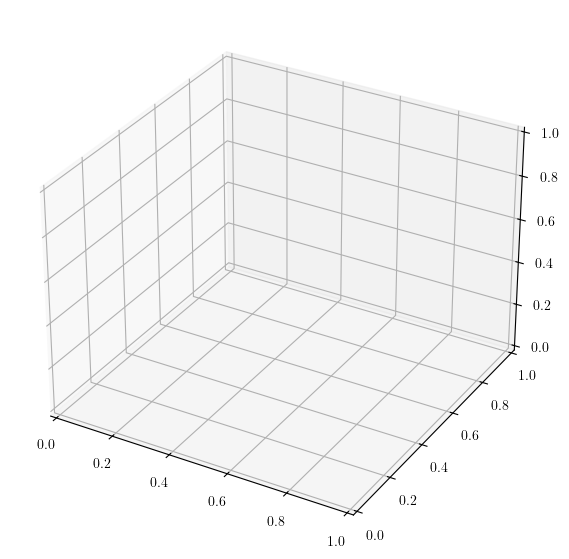

In [19]:
X = outliers[params].to_numpy()

mu, _, clu_points = trovo_adapation_routine(clusters={'nominal': cluster[params].to_numpy()}, 
                                            outliers=X, 
                                            options=options,
                                            times=outliers['time_step'].to_numpy())

# Plot results
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

colors = sns.color_palette("hls", 30)

# Original data points
if len(support) > 3:
    ax.scatter(mu[0], mu[1], mu[2], marker="x", s=100, color=colors[i], alpha=1)
    ax.scatter(clu_points[:, 0], clu_points[:, 1], clu_points[:, 2], color=colors[i], alpha=0.3, label=f"Support len {len(clu_points)}")

ax.set_xlabel("R0")
ax.set_ylabel("R1")
ax.set_zlabel("C1")
ax.set_title("Mountain Method (3D)")
ax.legend()

plt.show()

---

### Parameter Search with Round Robin

In [ ]:
import itertools
import numpy as np

def round_robin_opt(clusters, outliers, param_grid):
    # Convert dict of lists -> all combinations
    keys, values = zip(*param_grid.items())
    all_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
    
    results = []
    
    for i, params in enumerate(all_combinations):
        #print(f"\n=== Run {i+1}/{len(all_combinations)} with {params} ===")
        
        try:
            mus, sigmas, supports = adapation_routine(clusters, outliers, params)
            score = -np.inf
            for mu, sigma, support in zip(mus, sigmas, supports):
                score += score_cluster(mu, sigma, support, outliers)
            results.append((params, score))
            #print(f"✅ Score = {score:.4f}")
        except Exception as e:
            #print(f"❌ Failed with {params}, error: {e}")
            results.append((params, -np.inf))
    
    # Pick best
    results = sorted(results, key=lambda x: x[1], reverse=True)
    best_params, best_score = results[0]
    print(f"\n🏆 Best configuration: {best_params} with score {best_score:.4f}")
    return best_params, best_score, results

def score_cluster(mu, sigma, support, outliers):
    if sigma is None or len(support) == 0:
        return -np.inf
    det_cov = np.linalg.det(sigma)
    n_support = len(support)
    return n_support / (1.0 + det_cov)   # bigger = better


In [ ]:
param_grid = {
    'min_number_outliers': [10, 20, 30],
    'alpha_ks': [0.01, 0.05],
    'grid_size': [30, 40, 50],
    'radius': [0.1, 0.2, 0.5, 0.8],
    'support_fraction': [0.7, 0.8, 0.9],
    'k-neighbours': [10, 20, 30, 50],
    'distance': ['euclidean', 'maha'],
    'threshold_for_maha': ['fisher', 'chi2', 'empirical'],
    'alpha_mcd': [0.01, 0.05, 0.1, 0.2],
    'max_refine_iters': [0, 1]
}

In [3]:
best_params, best_score, all_results = round_robin_opt(
    clusters={'nominal': cluster[params].to_numpy()}, 
    outliers=outliers[params].to_numpy(),
    param_grid=param_grid
)

NameError: name 'round_robin_opt' is not defined